# 03 — RQ1: document-level sentiment classification

**RQ1.** How do Naive Bayes, Logistic Regression, and Gradient Boosting compare in document-level sentiment classification, and what do their systematic errors — particularly for 3-star reviews — reveal about the limitations of bag-of-words representations?

This notebook compares a majority-class baseline against Multinomial Naive Bayes, Logistic Regression and **scikit-learn GradientBoostingClassifier** on TF-IDF features, under both the binary and ternary framings, **with and without imbalance handling**. The headline metrics are **macro-F1 and per-class recall** — accuracy is reported only for reference.

**Methodology note (model selection without test-set leakage).** Earlier versions of this notebook chose features, imbalance handling and hyperparameters by repeatedly looking at the held-out 20% test set — a form of test-set leakage. This version fixes that with a strict **dev-train (64%) / validation (16%) / final-test (20%)** chronological split per category (`src.dataset.chronological_split_three_way`):

1. Feature representation (unigram vs. uni+bigram), imbalance handling, and a small deterministic hyperparameter grid for NB/LR/GB are all decided using **only** the validation slice.
2. Once a configuration is selected, it is retrained on the full oldest 80% (dev-train + validation) and evaluated **exactly once** on the newest 20% (final test).
3. A separate **matched-sample fair comparison** (identical 12,000 training rows for NB/LR/GB) and a **full-data operational comparison** (NB/LR only — see the note where Gradient Boosting is discussed) are reported as two distinct, clearly labelled result blocks.
4. Final-test metrics are reported with **class-stratified bootstrap confidence intervals** (2,000 replications, fixed seed), including a paired bootstrap for the unigram-vs-bigram macro-F1 difference.

> Runtime note: scikit-learn Gradient Boosting is trained on a deterministic stratified sample (`max_train_samples=12,000`) to keep the reproducible notebook runtime tractable. Naive Bayes and Logistic Regression fit on the full split in well under a few seconds; the validation-only hyperparameter grid search (Section 4) is the slowest part of this notebook (several minutes). Run top-to-bottom.

In [ ]:
import sys
from pathlib import Path

_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import sklearn
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
RANDOM_STATE = 42

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
MODELS_DIR = PROJECT_ROOT / 'models'
for d in (PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

NAVY, BLUE, ORANGE = '#1E3A6E', '#5B8DBF', '#D97757'


In [ ]:
from src import dataset, features, models, evaluation

df = pd.read_parquet(PROC_DIR / 'reviews_clean.parquet')
df = df[df['clean_text'].str.len() > 0].copy()   

dev_train_df, val_df, test_df = dataset.chronological_split_three_way(df)
dataset.assert_no_temporal_overlap(dev_train_df, val_df, test_df)

train_df, _ = dataset.chronological_split(df, test_size=0.2, by_category=True)
assert len(train_df) == len(dev_train_df) + len(val_df)

print(f'dev-train {len(dev_train_df):,} | validation {len(val_df):,} | final test {len(test_df):,} '
      f'| full oldest-80% (= dev-train + validation) {len(train_df):,}')

dev-train 55,983 | validation 13,997 | final test 17,495 | full oldest-80% (= dev-train + validation) 69,980


## 1. A reusable run helper

Each configuration fits on the (optionally resampled) dev-train split and is scored on the **validation** split — never on the final test set. The same helper is reused later for the final retrain-and-evaluate-once step, with dev-train+validation and the final test set passed in explicitly.

In [ ]:
def run_config(Xtr, ytr, Xte, yte, labels, model, resample=None):
    if resample:
        Xtr, ytr = models.resample_balanced(Xtr, ytr, strategy=resample)
    model.fit(Xtr, ytr)
    res = evaluation.evaluate_model(yte, model.predict(Xte), labels=labels)
    res['_model'] = model
    return res

def run_all(framing, col, labels, train_source, eval_source):
    """Fit on train_source, score on eval_source (dev-train/validation by default)."""
    tr, ev = dataset.prepare_task(train_source, eval_source, col)
    print(f'[{framing}] train {len(tr):,} eval {len(ev):,} | {tr[col].value_counts().to_dict()}')
    Xtr, Xev, vec = features.fit_transform_split(
        tr['clean_text'], ev['clean_text'], ngram_range=(1, 2), max_features=20000, min_df=5)
    ytr, yev = tr[col].values, ev[col].values
    res = {}
    res['majority_baseline']     = run_config(Xtr, ytr, Xev, yev, labels, models.get_majority_baseline())
    
    res['naive_bayes']           = run_config(Xtr, ytr, Xev, yev, labels, models.get_naive_bayes())
    res['logreg']                = run_config(Xtr, ytr, Xev, yev, labels, models.get_logistic_regression(class_weight=None))
    res['gboost']                = run_config(Xtr, ytr, Xev, yev, labels, models.get_gradient_boosting(class_weight=None))
    
    res['naive_bayes_resampled'] = run_config(Xtr, ytr, Xev, yev, labels, models.get_naive_bayes(), resample='undersample')
    res['logreg_balanced']       = run_config(Xtr, ytr, Xev, yev, labels, models.get_logistic_regression(class_weight='balanced'))
    res['gboost_balanced']       = run_config(Xtr, ytr, Xev, yev, labels, models.get_gradient_boosting(class_weight='balanced'))
    return res, ev, vec

## 2. Binary framing — illustrative imbalance-handling demonstration (validation only)

Negative (1-2★) vs positive (4-5★), 3★ dropped. This section illustrates *why* imbalance handling matters at all — it is **not** the basis for the final reported numbers (those come from Section 5, after configuration selection, evaluated once on the final test set). Everything here is fit on dev-train and scored on validation.

In [4]:
labels_b = ['positive', 'negative']
results_b, val_b, vec_b = run_all('binary', 'sentiment_binary', labels_b, dev_train_df, val_df)
cmp_b_val = evaluation.compare_models(results_b)
cmp_b_val.to_csv(TABLES_DIR / 'rq1_binary_validation_imbalance_demo.csv')
cmp_b_val

[binary] train 51,496 eval 12,960 | {'positive': 41784, 'negative': 9712}


,accuracy,f1_macro,f1_weighted,recall_macro,recall_positive,recall_negative
model,,,,,,
majority_baseline,0.7760,0.4369,0.6781,0.5000,1.0000,0.0000
naive_bayes,0.8794,0.7936,0.8671,0.7530,0.9820,0.5239
logreg,0.9119,0.8624,0.9080,0.8355,0.9738,0.6972
gboost,0.8399,0.7015,0.8137,0.6674,0.9799,0.3548
naive_bayes_resampled,0.8752,0.8404,0.8816,0.8879,0.8650,0.9108
logreg_balanced,0.9180,0.8876,0.9199,0.9077,0.9263,0.8891
gboost_balanced,0.8458,0.7762,0.8451,0.7737,0.9043,0.6431


**Reading (validation set).** The majority baseline reaches high accuracy but low macro-F1 and **zero recall on the negative class** — it never predicts negative. Without imbalance handling, all three models inherit a version of this. Switching on `class_weight='balanced'` (LR, GB) or undersampling (NB) lifts negative recall substantially with comparatively small macro-F1 cost. This validation-only run is illustrative, not the basis for model/feature selection — that happens next on the same validation slice, more systematically, in Section 4. (Exact figures printed above; see `rq1_binary_validation_imbalance_demo.csv`.)

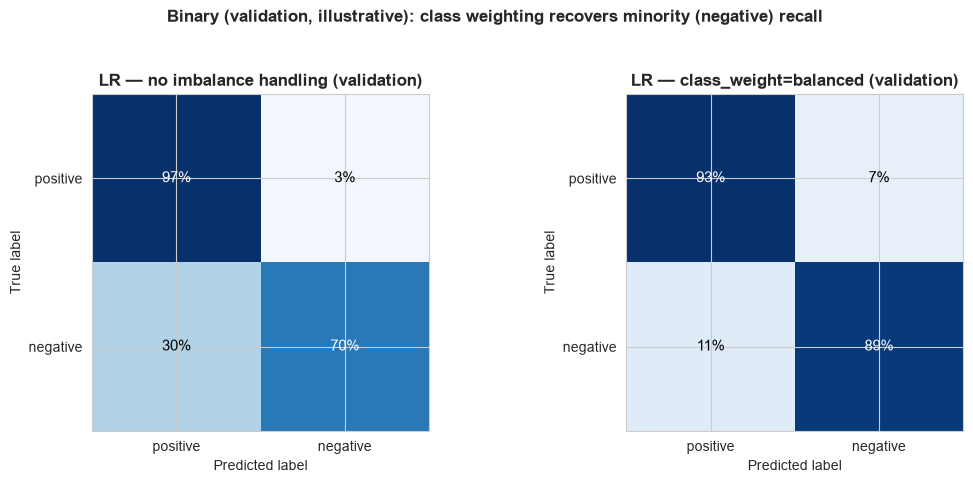

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
evaluation.plot_confusion_matrix(results_b['logreg']['confusion_matrix'], labels_b,
    'LR — no imbalance handling (validation)', ax=ax[0])
evaluation.plot_confusion_matrix(results_b['logreg_balanced']['confusion_matrix'], labels_b,
    'LR — class_weight=balanced (validation)', ax=ax[1])
plt.suptitle('Binary (validation, illustrative): class weighting recovers minority (negative) recall', fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_imbalance_demo_confusion_binary.png'); plt.show()

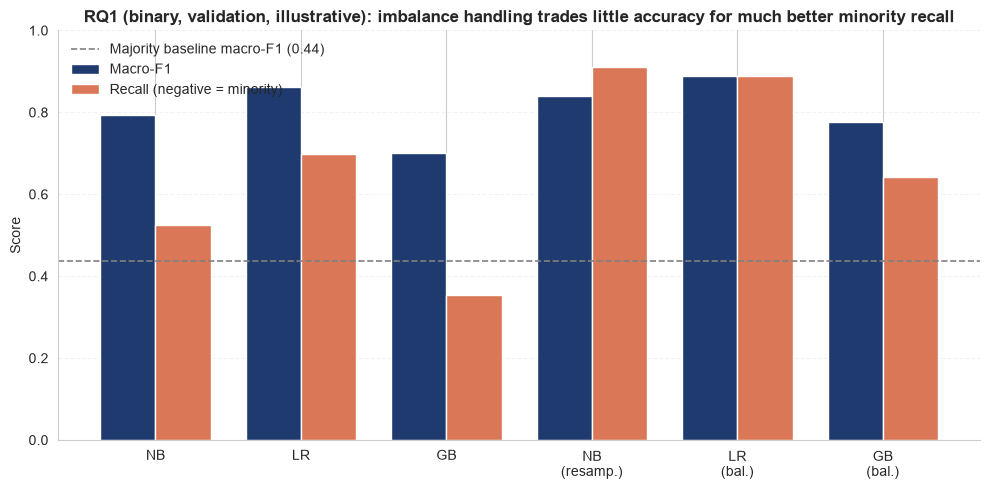

In [6]:
order = ['naive_bayes', 'logreg', 'gboost', 'naive_bayes_resampled', 'logreg_balanced', 'gboost_balanced']
disp  = ['NB', 'LR', 'GB', 'NB\n(resamp.)', 'LR\n(bal.)', 'GB\n(bal.)']
neg = labels_b.index('negative')
f1   = [results_b[k]['f1_macro'] for k in order]
rneg = [results_b[k]['recall_per_class'][neg] for k in order]
x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, f1, w, label='Macro-F1', color=NAVY)
ax.bar(x + w/2, rneg, w, label='Recall (negative = minority)', color=ORANGE)
mb = results_b['majority_baseline']['f1_macro']
ax.axhline(mb, ls='--', color='gray', lw=1.2, label=f'Majority baseline macro-F1 ({mb:.2f})')
ax.set_xticks(x); ax.set_xticklabels(disp); ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title('RQ1 (binary, validation, illustrative): imbalance handling trades little accuracy for much better minority recall', fontweight='bold')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_imbalance_comparison.png'); plt.show()

## 3. Ternary framing — illustrative imbalance-handling demonstration (validation only)

Adds the 3★ neutral class — the minority, and the population RQ1 most wants to probe. As in Section 2, this is fit on dev-train and scored on validation; it motivates *why* imbalance handling matters but is not itself the final reported result.

In [7]:
labels_t = ['positive', 'neutral', 'negative']
results_t, val_t, vec_t = run_all('ternary', 'sentiment_ternary', labels_t, dev_train_df, val_df)
cmp_t_val = evaluation.compare_models(results_t)
cmp_t_val.to_csv(TABLES_DIR / 'rq1_ternary_validation_imbalance_demo.csv')
cmp_t_val

[ternary] train 55,983 eval 13,997 | {'positive': 41784, 'negative': 9712, 'neutral': 4487}


,accuracy,f1_macro,f1_weighted,recall_macro,recall_positive,recall_neutral,recall_negative
model,,,,,,,
majority_baseline,0.7185,0.2787,0.6008,0.3333,1.0000,0.0000,0.0000
naive_bayes,0.8141,0.5117,0.7729,0.5038,0.9818,0.0087,0.5208
logreg,0.8506,0.6168,0.8299,0.5990,0.9677,0.1254,0.7041
gboost,0.7810,0.4715,0.7323,0.4574,0.9795,0.0318,0.3610
naive_bayes_resampled,0.7344,0.6004,0.7734,0.6634,0.7732,0.5516,0.6655
logreg_balanced,0.8128,0.6514,0.8297,0.6802,0.8795,0.4494,0.7117
gboost_balanced,0.7694,0.5765,0.7728,0.5785,0.8801,0.3028,0.5525


In [ ]:
metadata_rows = []
for framing, results, train_col in [
    ('binary', results_b, 'sentiment_binary'),
    ('ternary', results_t, 'sentiment_ternary'),
]:
    train_task, _ = dataset.prepare_task(dev_train_df, val_df, train_col)
    for key in ['gboost', 'gboost_balanced']:
        gb = results[key]['_model']
        params = gb.get_params()
        metadata_rows.append({
            'framing': framing,
            'model_key': key,
            'split': 'dev_train -> validation (illustrative demo, not final test)',
            'implementation': 'sklearn.ensemble.GradientBoostingClassifier',
            'sklearn_version': sklearn.__version__,
            'random_state': params['random_state'],
            'n_estimators': params['n_estimators'],
            'learning_rate': params['learning_rate'],
            'max_depth': params['max_depth'],
            'class_weight_or_sample_weight': params['class_weight'],
            'train_split_n': len(train_task),
            'fit_n_samples': getattr(gb, 'fit_n_samples_', None),
            'fit_sampled': getattr(gb, 'fit_sampled_', None),
            'max_train_samples': params['max_train_samples'],
        })
metadata = pd.DataFrame(metadata_rows)
metadata.to_csv(TABLES_DIR / 'rq1_gradient_boosting_metadata.csv', index=False)
metadata.to_json(TABLES_DIR / 'rq1_gradient_boosting_metadata.json', orient='records', indent=2)
metadata

,framing,model_key,split,implementation,sklearn_version,random_state,n_estimators,learning_rate,max_depth,class_weight_or_sample_weight,train_split_n,fit_n_samples,fit_sampled,max_train_samples
0,binary,gboost,"dev_train -> validation (illustrative demo, no...",sklearn.ensemble.GradientBoostingClassifier,1.9.0,42,40,0.05,3,NaN,51496,12000,True,12000
1,binary,gboost_balanced,"dev_train -> validation (illustrative demo, no...",sklearn.ensemble.GradientBoostingClassifier,1.9.0,42,40,0.05,3,balanced,51496,12000,True,12000
2,ternary,gboost,"dev_train -> validation (illustrative demo, no...",sklearn.ensemble.GradientBoostingClassifier,1.9.0,42,40,0.05,3,NaN,55983,12000,True,12000
3,ternary,gboost_balanced,"dev_train -> validation (illustrative demo, no...",sklearn.ensemble.GradientBoostingClassifier,1.9.0,42,40,0.05,3,balanced,55983,12000,True,12000


**Reading (validation set).** This is where imbalance bites hardest. Without handling, Naive Bayes predicts the neutral class with a recall on the order of 1% — a textbook minority-class collapse — and even Logistic Regression manages only a modest fraction. Balancing raises both models' neutral recall substantially, but at a real accuracy cost. The 3★ class never becomes easy: these reviews genuinely mix positive and negative sentiment, which is precisely the limitation RQ1 set out to characterise and motivates both the dedicated 3-star analysis later in this notebook (Section 10) and the sentence-level view in RQ2. This persistent difficulty is observed consistently across independent held-out sets (it also reproduces on the final test set in Section 5), so it is treated as a genuine property of the task under this bag-of-words setup, not a one-off artefact of a single split — but it is reported as "persistent difficulty under the evaluated setup," not as a provable, universal ceiling for every possible classical method. (Exact figures printed above; see `rq1_ternary_validation_imbalance_demo.csv`.)

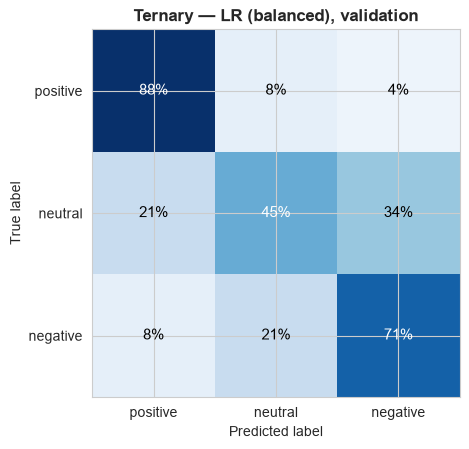

In [9]:
fig, ax = plt.subplots(figsize=(5.2, 4.6))
evaluation.plot_confusion_matrix(results_t['logreg_balanced']['confusion_matrix'], labels_t,
    'Ternary — LR (balanced), validation', ax=ax)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_imbalance_demo_confusion_ternary.png'); plt.show()

## 4. Validation-only selection: features, imbalance handling, hyperparameters

This is where the actual configuration used for the final test evaluation gets decided — **using only the validation slice**. Three sequential decisions:

1. **Feature representation** (unigram vs. uni+bigram) with a fixed reference model (LR, balanced).
2. **Imbalance handling and hyperparameters**, via a small deterministic grid per model family, using the feature representation chosen in step 1.
3. The single best configuration overall (by validation macro-F1, minority-class recall as tie-breaker) becomes the model retrained on the full oldest 80% and evaluated once on the final test set in Section 5.

In [10]:
def decide_features(label_col, labels):
    tr, va = dataset.prepare_task(dev_train_df, val_df, label_col)
    ytr, yva = tr[label_col].values, va[label_col].values
    rows = []
    for fname, kw in features.FEATURE_CONFIGS.items():
        Xtr, Xva, _ = features.fit_transform_split(tr['clean_text'], va['clean_text'],
                                                     max_features=20000, min_df=5, **kw)
        m = models.get_logistic_regression(class_weight='balanced')
        m.fit(Xtr, ytr)
        r = evaluation.evaluate_model(yva, m.predict(Xva), labels=labels)
        rows.append({'features': fname, 'n_features': Xtr.shape[1], 'f1_macro': r['f1_macro'],
                     'accuracy': r['accuracy']})
    return pd.DataFrame(rows).set_index('features').round(4)

print('--- 4.1 Feature decision (binary), validation ---')
feat_cmp_b = decide_features('sentiment_binary', labels_b)
print(feat_cmp_b)

print('\n--- 4.1 Feature decision (ternary), validation ---')
feat_cmp_t = decide_features('sentiment_ternary', labels_t)
print(feat_cmp_t)

pd.concat([feat_cmp_b.assign(framing='binary'), feat_cmp_t.assign(framing='ternary')]).to_csv(
    TABLES_DIR / 'rq1_feature_comparison.csv')

SELECTED_NGRAM_RANGE = (1, 2) if feat_cmp_b.loc['tfidf_uni_bigram', 'f1_macro'] >= feat_cmp_b.loc['tfidf_unigram', 'f1_macro'] else (1, 1)
print(f'\nSelected feature representation (by validation macro-F1, binary framing leads): {SELECTED_NGRAM_RANGE}')

--- 4.1 Feature decision (binary), validation ---


                  n_features  f1_macro  accuracy
features                                        
tfidf_unigram           8341    0.8723     0.905
tfidf_uni_bigram       20000    0.8876     0.918

--- 4.1 Feature decision (ternary), validation ---


                  n_features  f1_macro  accuracy
features                                        
tfidf_unigram           8819    0.6356    0.7923
tfidf_uni_bigram       20000    0.6514    0.8128

Selected feature representation (by validation macro-F1, binary framing leads): (1, 2)


**Reading (validation set).** Adding bigrams roughly doubles the vocabulary for an observed macro-F1 gain in both framings (exact figures printed above; see `rq1_feature_comparison.csv`). Bigrams capture negations and short phrases ("not worth", "highly recommend") that unigrams miss. Whether this gain is distinguishable from noise on the final test set, with a confidence interval, is checked properly in Section 6 (paired bootstrap) rather than asserted here. The selection above uses validation macro-F1 (binary framing leading) and is computed programmatically from the table, not hardcoded.

### 4.2 Hyperparameter + imbalance-handling grid search (validation only)

A small, deterministic, computationally realistic grid per model family, fit on dev-train and scored on validation with the selected features:

- **Naive Bayes:** `alpha` ∈ {0.1, 0.5, 1.0, 2.0}, crossed with {no handling, reproducible undersampling}.
- **Logistic Regression:** `C` ∈ {0.1, 0.5, 1.0, 2.0, 5.0} × `class_weight` ∈ {None, balanced}.
- **Gradient Boosting:** `n_estimators` ∈ {40, 80} × `learning_rate` ∈ {0.05, 0.1} × `max_depth` ∈ {2, 3} × `class_weight` ∈ {None, balanced}, on the same deterministic 12,000-sample cap used everywhere else.

Selection criterion: **validation macro-F1** (primary), **minority-class recall** as a transparent tie-breaker (`src.models.select_best_config`). No candidate ever sees the final test set.

In [11]:
MINORITY = {'sentiment_binary': 'negative', 'sentiment_ternary': 'neutral'}

def grid_search(label_col, labels):
    tr, va = dataset.prepare_task(dev_train_df, val_df, label_col)
    ytr, yva = tr[label_col].values, va[label_col].values
    Xtr, Xva, _ = features.fit_transform_split(tr['clean_text'], va['clean_text'],
                                                 ngram_range=SELECTED_NGRAM_RANGE, max_features=20000, min_df=5)
    minority = MINORITY[label_col]
    candidates = []

    for alpha in models.NB_ALPHA_GRID:
        for resample in [None, 'undersample']:
            Xtr_use, ytr_use = (Xtr, ytr) if resample is None else models.resample_balanced(Xtr, ytr, strategy=resample)
            m = models.get_naive_bayes(alpha=alpha)
            m.fit(Xtr_use, ytr_use)
            r = evaluation.evaluate_model(yva, m.predict(Xva), labels=labels)
            candidates.append({'family': 'naive_bayes', 'name': f'nb_alpha{alpha}_{resample or "none"}',
                                'alpha': alpha, 'resample': resample or 'none',
                                'f1_macro': r['f1_macro'], 'accuracy': r['accuracy'],
                                f'recall_{minority}': r['recall_per_class'][labels.index(minority)]})

    for C in models.LR_C_GRID:
        for cw in models.LR_CLASS_WEIGHT_GRID:
            m = models.get_logistic_regression(class_weight=cw, C=C)
            m.fit(Xtr, ytr)
            r = evaluation.evaluate_model(yva, m.predict(Xva), labels=labels)
            candidates.append({'family': 'logistic_regression', 'name': f'lr_C{C}_{cw or "none"}',
                                'C': C, 'class_weight': cw or 'none',
                                'f1_macro': r['f1_macro'], 'accuracy': r['accuracy'],
                                f'recall_{minority}': r['recall_per_class'][labels.index(minority)]})

    for n_est in models.GB_N_ESTIMATORS_GRID:
        for lr_rate in models.GB_LEARNING_RATE_GRID:
            for depth in models.GB_MAX_DEPTH_GRID:
                for cw in models.GB_CLASS_WEIGHT_GRID:
                    m = models.get_gradient_boosting(class_weight=cw, n_estimators=n_est,
                                                       learning_rate=lr_rate, max_depth=depth)
                    m.fit(Xtr, ytr)
                    r = evaluation.evaluate_model(yva, m.predict(Xva), labels=labels)
                    candidates.append({'family': 'gradient_boosting',
                                        'name': f'gb_n{n_est}_lr{lr_rate}_d{depth}_{cw or "none"}',
                                        'n_estimators': n_est, 'learning_rate': lr_rate, 'max_depth': depth,
                                        'class_weight': cw or 'none',
                                        'f1_macro': r['f1_macro'], 'accuracy': r['accuracy'],
                                        f'recall_{minority}': r['recall_per_class'][labels.index(minority)]})

    return models.select_best_config(candidates, minority_label=minority)

print('=== Grid search (binary), validation ===')
ranked_b = grid_search('sentiment_binary', labels_b)
ranked_b.to_csv(TABLES_DIR / 'rq1_hyperparameter_search_binary.csv', index=False)
print(ranked_b.head(8).to_string(index=False))

print('\n=== Grid search (ternary), validation ===')
ranked_t = grid_search('sentiment_ternary', labels_t)
ranked_t.to_csv(TABLES_DIR / 'rq1_hyperparameter_search_ternary.csv', index=False)
print(ranked_t.head(8).to_string(index=False))

=== Grid search (binary), validation ===


             family             name  alpha resample  f1_macro  accuracy  recall_negative   C class_weight  n_estimators  learning_rate  max_depth  selected
logistic_regression lr_C2.0_balanced    NaN      NaN  0.888160  0.918904         0.880813 2.0     balanced           NaN            NaN        NaN      True
logistic_regression lr_C1.0_balanced    NaN      NaN  0.887632  0.917978         0.889080 1.0     balanced           NaN            NaN        NaN     False
logistic_regression lr_C5.0_balanced    NaN      NaN  0.886707  0.918904         0.861178 5.0     balanced           NaN            NaN        NaN     False
logistic_regression lr_C0.5_balanced    NaN      NaN  0.883298  0.914275         0.890803 0.5     balanced           NaN            NaN        NaN     False
logistic_regression     lr_C5.0_none    NaN      NaN  0.876925  0.918904         0.747503 5.0         none           NaN            NaN        NaN     False
logistic_regression     lr_C2.0_none    NaN      NaN  0.87

             family             name  alpha resample  f1_macro  accuracy  recall_neutral   C class_weight  n_estimators  learning_rate  max_depth  selected
logistic_regression lr_C0.5_balanced    NaN      NaN  0.652617  0.810817        0.472517 0.5     balanced           NaN            NaN        NaN      True
logistic_regression lr_C1.0_balanced    NaN      NaN  0.651373  0.812817        0.449373 1.0     balanced           NaN            NaN        NaN     False
logistic_regression lr_C2.0_balanced    NaN      NaN  0.646310  0.812674        0.418515 2.0     balanced           NaN            NaN        NaN     False
logistic_regression lr_C0.1_balanced    NaN      NaN  0.641405  0.793241        0.508197 0.1     balanced           NaN            NaN        NaN     False
logistic_regression lr_C5.0_balanced    NaN      NaN  0.639912  0.811745        0.386692 5.0     balanced           NaN            NaN        NaN     False
logistic_regression     lr_C5.0_none    NaN      NaN  0.628276  

**Reading (validation set).** The ranked tables above show, per model family, the best validation configuration found in this grid, with the single best overall (by validation macro-F1, minority recall as tie-breaker) marked `selected=True` — this selection happens entirely on validation data, before the final test set is inspected. The winning family/configuration is read off programmatically below (Section 5), not hardcoded, so this notebook reflects whichever family the validation grid actually favours.

## 5. Final configuration: retrain on the full oldest 80%, evaluate once

The configuration selected on validation (Section 4, `selected=True` row) is retrained on the full oldest-80% pool (`train_df` = dev-train + validation) and evaluated **exactly once** on the final, previously untouched 20% test set. These are the headline RQ1 numbers used in the paper. The winning family is read off `ranked_b`/`ranked_t` programmatically — this notebook does not assume in advance which family wins.

In [12]:
def build_selected_model(row):
    """Construct the model object (and an optional resample strategy) for a
    selected validation-grid row, regardless of which family won."""
    family = row['family']
    if family == 'naive_bayes':
        resample = None if row['resample'] == 'none' else row['resample']
        return models.get_naive_bayes(alpha=float(row['alpha'])), resample
    if family == 'logistic_regression':
        cw = None if row['class_weight'] == 'none' else row['class_weight']
        return models.get_logistic_regression(class_weight=cw, C=float(row['C'])), None
    if family == 'gradient_boosting':
        cw = None if row['class_weight'] == 'none' else row['class_weight']
        return models.get_gradient_boosting(class_weight=cw, n_estimators=int(row['n_estimators']),
                                             learning_rate=float(row['learning_rate']),
                                             max_depth=int(row['max_depth'])), None
    raise ValueError(f'Unknown family: {family}')

SELECTED_ROW = {'sentiment_binary': ranked_b.iloc[0], 'sentiment_ternary': ranked_t.iloc[0]}
SELECTED_LABELS = {'sentiment_binary': labels_b, 'sentiment_ternary': labels_t}

final = {}
final_rows = {}
for label_col, row in SELECTED_ROW.items():
    labels = SELECTED_LABELS[label_col]
    tr, te = dataset.prepare_task(train_df, test_df, label_col)
    ytr, yte = tr[label_col].values, te[label_col].values
    Xtr, Xte, vec = features.fit_transform_split(tr['clean_text'], te['clean_text'],
                                                   ngram_range=SELECTED_NGRAM_RANGE, max_features=20000, min_df=5)
    m, resample = build_selected_model(row)
    Xtr_fit, ytr_fit = (Xtr, ytr) if resample is None else models.resample_balanced(Xtr, ytr, strategy=resample)
    m.fit(Xtr_fit, ytr_fit)
    pred = m.predict(Xte)
    proba = m.predict_proba(Xte)
    r = evaluation.evaluate_model(yte, pred, labels=labels)
    final[label_col] = {'model': m, 'vec': vec, 'Xtr': Xtr, 'Xte': Xte, 'ytr': ytr, 'yte': yte,
                         'pred': pred, 'proba': proba, 'tr': tr, 'te': te, 'labels': labels,
                         'selected_name': row['name'], 'selected_family': row['family']}
    final_rows[label_col] = {'model': row['name'], 'family': row['family'], 'accuracy': r['accuracy'],
                              'f1_macro': r['f1_macro'], 'f1_weighted': r['f1_weighted'],
                              **{f'recall_{lbl}': rec for lbl, rec in zip(labels, r['recall_per_class'])}}

cmp_b_final = pd.DataFrame([final_rows['sentiment_binary']]).set_index('model').round(4)
cmp_t_final = pd.DataFrame([final_rows['sentiment_ternary']]).set_index('model').round(4)
cmp_b_final.to_csv(TABLES_DIR / 'rq1_binary_comparison.csv')
cmp_t_final.to_csv(TABLES_DIR / 'rq1_ternary_comparison.csv')
evaluation.results_to_latex(cmp_b_final, TABLES_DIR / 'rq1_binary_comparison.tex',
    caption='RQ1 final-test result, binary framing (selected configuration, single evaluation).', label='tab:rq1_binary')
evaluation.results_to_latex(cmp_t_final, TABLES_DIR / 'rq1_ternary_comparison.tex',
    caption='RQ1 final-test result, ternary framing (selected configuration, single evaluation).', label='tab:rq1_ternary')

print('FINAL TEST — binary (selected:', final['sentiment_binary']['selected_name'], '):')
print(cmp_b_final)
print('\nFINAL TEST — ternary (selected:', final['sentiment_ternary']['selected_name'], '):')
print(cmp_t_final)

FINAL TEST — binary (selected: lr_C2.0_balanced ):
                               family  accuracy  f1_macro  f1_weighted  \
model                                                                    
lr_C2.0_balanced  logistic_regression    0.9016    0.8879       0.9027   

                  recall_positive  recall_negative  
model                                               
lr_C2.0_balanced           0.9095           0.8843  

FINAL TEST — ternary (selected: lr_C0.5_balanced ):
                               family  accuracy  f1_macro  f1_weighted  \
model                                                                    
lr_C0.5_balanced  logistic_regression    0.7853    0.6442       0.8061   

                  recall_positive  recall_neutral  recall_negative  
model                                                               
lr_C0.5_balanced           0.8476          0.4479           0.7308  


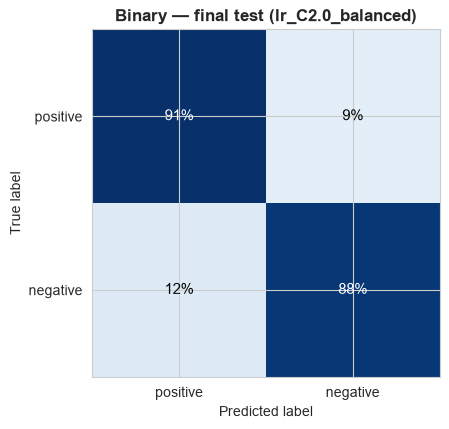

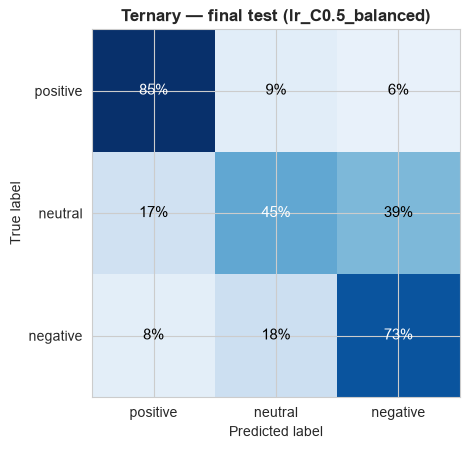

,n_test,accuracy,f1_macro,recall_positive,recall_negative
category,,,,,
Magazine_Subscriptions,13354,0.9075,0.8944,0.9199,0.8806
Subscription_Boxes,2893,0.8745,0.8579,0.8627,0.9027


In [13]:
r_b_final = evaluation.evaluate_model(final['sentiment_binary']['yte'], final['sentiment_binary']['pred'], labels=labels_b)
r_t_final = evaluation.evaluate_model(final['sentiment_ternary']['yte'], final['sentiment_ternary']['pred'], labels=labels_t)

fig, ax = plt.subplots(figsize=(5.0, 4.4))
evaluation.plot_confusion_matrix(r_b_final['confusion_matrix'], labels_b,
    f"Binary — final test ({final['sentiment_binary']['selected_name']})", ax=ax)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_confusion_binary.png'); plt.show()

fig, ax = plt.subplots(figsize=(5.2, 4.6))
evaluation.plot_confusion_matrix(r_t_final['confusion_matrix'], labels_t,
    f"Ternary — final test ({final['sentiment_ternary']['selected_name']})", ax=ax)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_confusion_ternary.png'); plt.show()

# Final-test performance by category (binary).
te_b_reset = final['sentiment_binary']['te'].reset_index(drop=True)
pred_b_final = final['sentiment_binary']['pred']
cat_rows = []
for cat, idx in te_b_reset.groupby('category').groups.items():
    idx = list(idx)
    r = evaluation.evaluate_model(te_b_reset['sentiment_binary'].iloc[idx].values, pred_b_final[idx], labels=labels_b)
    cat_rows.append({'category': cat, 'n_test': len(idx), 'accuracy': r['accuracy'], 'f1_macro': r['f1_macro'],
                      'recall_positive': r['recall_per_class'][labels_b.index('positive')],
                      'recall_negative': r['recall_per_class'][labels_b.index('negative')]})
rq1_by_cat = pd.DataFrame(cat_rows).set_index('category').round(4)
rq1_by_cat.to_csv(TABLES_DIR / 'rq1_binary_by_category.csv')
rq1_by_cat

**Reading (final test, single evaluation).** Exact figures are printed above (`rq1_binary_comparison.csv`, `rq1_ternary_comparison.csv`, `rq1_binary_by_category.csv`) — the selected configuration's macro-F1 and per-class recall on the final test set, and the by-category breakdown confirming the combined classifier is not simply learning the larger category at the expense of the smaller one. The accuracy-vs-minority-recall trade-off visible on validation (Section 3) reproduces here: balancing helps minority recall but costs some accuracy under the ternary framing — the genuine trade-off this notebook documents rather than papers over.

## 6. Statistical uncertainty: bootstrap confidence intervals (final test)

**Class-stratified** non-parametric bootstrap, 2,000 replications, fixed seed, 95% percentile CIs (`src.evaluation.bootstrap_classification_report_ci`) for accuracy, macro-F1 and per-true-class recall — each replication resamples *within* each true-class stratum at that stratum's original size (`src.evaluation._stratified_bootstrap_indices`), so class proportions are fixed across replications rather than also varying by chance. Then a **paired** bootstrap (`src.evaluation.paired_bootstrap_macro_f1_diff`), using the same stratified resampling, for the unigram-vs-uni+bigram macro-F1 difference: both feature configurations retrained on the full oldest 80% and evaluated on the **same** resampled test indices in every replication, so the comparison is paired, not independent.

In [14]:
ci_b = evaluation.bootstrap_classification_report_ci(final['sentiment_binary']['yte'], final['sentiment_binary']['pred'],
                                                       labels=labels_b, n_replications=2000, random_state=42)
ci_t = evaluation.bootstrap_classification_report_ci(final['sentiment_ternary']['yte'], final['sentiment_ternary']['pred'],
                                                       labels=labels_t, n_replications=2000, random_state=42)
ci_b.to_csv(TABLES_DIR / 'rq1_bootstrap_ci_binary.csv', index=False)
ci_t.to_csv(TABLES_DIR / 'rq1_bootstrap_ci_ternary.csv', index=False)
evaluation.results_to_latex(ci_b.set_index('metric'), TABLES_DIR / 'rq1_bootstrap_ci_binary.tex',
    caption='Class-stratified bootstrap 95\\% CIs (2{,}000 replications), final test, binary framing.', label='tab:rq1_bootstrap_binary')
evaluation.results_to_latex(ci_t.set_index('metric'), TABLES_DIR / 'rq1_bootstrap_ci_ternary.tex',
    caption='Class-stratified bootstrap 95\\% CIs (2{,}000 replications), final test, ternary framing.', label='tab:rq1_bootstrap_ternary')
print('Binary (final test) bootstrap CIs:')
print(ci_b.to_string(index=False))
print('\nTernary (final test) bootstrap CIs:')
print(ci_t.to_string(index=False))

Binary (final test) bootstrap CIs:
         metric  point_estimate  ci_low  ci_high
       accuracy          0.9016  0.8971   0.9063
       f1_macro          0.8879  0.8829   0.8932
recall_positive          0.9095  0.9042   0.9147
recall_negative          0.8843  0.8754   0.8930

Ternary (final test) bootstrap CIs:
         metric  point_estimate  ci_low  ci_high
       accuracy          0.7853  0.7794   0.7912
       f1_macro          0.6442  0.6365   0.6521
recall_positive          0.8476  0.8411   0.8539
 recall_neutral          0.4479  0.4207   0.4752
recall_negative          0.7308  0.7185   0.7432


In [ ]:
tr_b_full, te_b_full = dataset.prepare_task(train_df, test_df, 'sentiment_binary')
ytr_full_b, yte_full_b = tr_b_full['sentiment_binary'].values, te_b_full['sentiment_binary'].values
binary_row = SELECTED_ROW['sentiment_binary']

Xtr_uni, Xte_uni, _ = features.fit_transform_split(tr_b_full['clean_text'], te_b_full['clean_text'],
                                                     ngram_range=(1, 1), max_features=20000, min_df=5)
Xtr_bi, Xte_bi, _ = features.fit_transform_split(tr_b_full['clean_text'], te_b_full['clean_text'],
                                                   ngram_range=(1, 2), max_features=20000, min_df=5)

m_uni, resample_uni = build_selected_model(binary_row)
m_bi, resample_bi = build_selected_model(binary_row)
Xtr_uni_fit, ytr_uni_fit = (Xtr_uni, ytr_full_b) if resample_uni is None else models.resample_balanced(Xtr_uni, ytr_full_b, strategy=resample_uni)
Xtr_bi_fit, ytr_bi_fit = (Xtr_bi, ytr_full_b) if resample_bi is None else models.resample_balanced(Xtr_bi, ytr_full_b, strategy=resample_bi)
m_uni.fit(Xtr_uni_fit, ytr_uni_fit)
m_bi.fit(Xtr_bi_fit, ytr_bi_fit)
pred_uni, pred_bi = m_uni.predict(Xte_uni), m_bi.predict(Xte_bi)

paired = evaluation.paired_bootstrap_macro_f1_diff(
    yte_full_b, pred_uni, pred_bi, labels=labels_b, n_replications=2000, random_state=42,
    name_a='unigram', name_b='uni_bigram')
pd.DataFrame([paired]).to_csv(TABLES_DIR / 'rq1_paired_bootstrap_unigram_vs_bigram.csv', index=False)
print(f"Paired bootstrap (final test, binary, selected config {binary_row['name']}): unigram vs. uni+bigram macro-F1")
for k, v in paired.items():
    print(f'  {k}: {v}')

Paired bootstrap (final test, binary, selected config lr_C2.0_balanced): unigram vs. uni+bigram macro-F1
  f1_macro_unigram: 0.8752717897181963
  f1_macro_uni_bigram: 0.8878986454455531
  diff: 0.012626855727356778
  ci_low: 0.00905828092246821
  ci_high: 0.0160809337280965
  ci_excludes_zero: True
  interpretation: stable difference under this holdout
  n_replications: 2000
  random_state: 42


**Reading.** The final-test bootstrap CIs (binary and ternary) show the precision of every headline metric directly — see the two CSVs for exact bounds. For the unigram-vs-bigram comparison: the paired-bootstrap 95% CI of the macro-F1 difference is computed on the same stratified-resampled test indices for both feature configurations. If that CI **excludes zero**, the gain is reported as a *stable difference under this holdout* (not as a "real" or "significant" improvement in a hypothesis-testing sense — no formal significance test was run, only a percentile bootstrap CI); if the CI **includes zero**, it is reported as a *small observed gain* and nothing stronger. The exact verdict is in the printed `interpretation` field above and is what the paper text quotes verbatim.

## 7. Fair model-family comparison (binary framing)

Two distinct, clearly labelled blocks, evaluated on the same final test set:

**Block A — matched-sample fair comparison.** NB, LR and Gradient Boosting all train on the **exact same** 12,000 deterministically selected dev-train rows (`src.dataset.deterministic_stratified_sample`), the same TF-IDF features fit on that sample, the same final test set. NB uses its validation-selected hyperparameters without resampling (so all three see literally identical training rows); LR and GB use their validation-selected hyperparameters. This isolates *model-family capability* from *training-data volume* — it is the fair comparison of model families.

**Block B — full-data operational comparison.** NB and LR trained on the full oldest-80% pool. **Gradient Boosting is excluded from this block**: its implementation internally caps training at `max_train_samples=12,000` regardless of how much data is passed in (see `src/models.py`), so a "full-data" GB row would not actually train on more data than Block A and would misrepresent the comparison as a full-data result.

In [ ]:
ranked_b_no_nb_resample = ranked_b[~((ranked_b['family'] == 'naive_bayes') & (ranked_b['resample'] == 'undersample'))]
best_per_family_b = ranked_b_no_nb_resample.sort_values(
    ['f1_macro', f'recall_{MINORITY["sentiment_binary"]}'], ascending=[False, False]
).drop_duplicates(subset='family', keep='first').set_index('family')
print('Best validation configuration per family for the matched-sample block (binary; NB restricted to no resampling):')
print(best_per_family_b[['name', 'f1_macro']])

matched = dataset.deterministic_stratified_sample(tr_b_full, 'sentiment_binary', n=12000, random_state=42)
Xtr_m, Xte_m, vec_m = features.fit_transform_split(matched['clean_text'], te_b_full['clean_text'],
                                                     ngram_range=SELECTED_NGRAM_RANGE, max_features=20000, min_df=5)
ytr_m, yte_m = matched['sentiment_binary'].values, te_b_full['sentiment_binary'].values
print('\nMatched-sample class balance:', matched['sentiment_binary'].value_counts().to_dict())

block_a_rows = []
for family in ['naive_bayes', 'logistic_regression', 'gradient_boosting']:
    row = best_per_family_b.loc[family]
    m, resample = build_selected_model(pd.Series({**row.to_dict(), 'family': family}))
    assert resample is None, 'Block A requires identical training rows for every family'
    m.fit(Xtr_m, ytr_m)
    r = evaluation.evaluate_model(yte_m, m.predict(Xte_m), labels=labels_b)
    block_a_rows.append({'model': family, 'config': row['name'], 'n_train': Xtr_m.shape[0],
                          'accuracy': r['accuracy'], 'f1_macro': r['f1_macro'],
                          'recall_positive': r['recall_per_class'][0], 'recall_negative': r['recall_per_class'][1]})
block_a = pd.DataFrame(block_a_rows).set_index('model').round(4)
block_a.to_csv(TABLES_DIR / 'rq1_matched_sample_comparison.csv')
print('\nBlock A — matched-sample (n=12,000) fair comparison, identical training rows for all three families:')
print(block_a)

Best validation configuration per family for the matched-sample block (binary; NB restricted to no resampling):
                                         name  f1_macro
family                                                 
logistic_regression          lr_C2.0_balanced  0.888160
naive_bayes                  nb_alpha0.1_none  0.829148
gradient_boosting    gb_n80_lr0.1_d3_balanced  0.815491



Matched-sample class balance: {'positive': 9651, 'negative': 2349}



Block A — matched-sample (n=12,000) fair comparison, identical training rows for all three families:
                                       config  n_train  accuracy  f1_macro  \
model                                                                        
naive_bayes                  nb_alpha0.1_none    12000    0.8549    0.8137   
logistic_regression          lr_C2.0_balanced    12000    0.8914    0.8756   
gradient_boosting    gb_n80_lr0.1_d3_balanced    12000    0.8406    0.8148   

                     recall_positive  recall_negative  
model                                                  
naive_bayes                   0.9631           0.6163  
logistic_regression           0.9064           0.8581  
gradient_boosting             0.8819           0.7495  


In [ ]:
best_per_family_b_full = ranked_b.sort_values(
    ['f1_macro', f'recall_{MINORITY["sentiment_binary"]}'], ascending=[False, False]
).drop_duplicates(subset='family', keep='first').set_index('family')

block_b_rows = []
for family in ['naive_bayes', 'logistic_regression']:
    row = best_per_family_b_full.loc[family]
    m, resample = build_selected_model(pd.Series({**row.to_dict(), 'family': family}))
    Xtr_use, ytr_use = (Xtr_bi, ytr_full_b) if resample is None else models.resample_balanced(Xtr_bi, ytr_full_b, strategy=resample)
    m.fit(Xtr_use, ytr_use)
    r = evaluation.evaluate_model(yte_full_b, m.predict(Xte_bi), labels=labels_b)
    block_b_rows.append({'model': family, 'config': row['name'], 'n_train': Xtr_use.shape[0],
                          'accuracy': r['accuracy'], 'f1_macro': r['f1_macro'],
                          'recall_positive': r['recall_per_class'][0], 'recall_negative': r['recall_per_class'][1]})
block_b = pd.DataFrame(block_b_rows).set_index('model').round(4)
block_b.to_csv(TABLES_DIR / 'rq1_full_data_comparison.csv')
print('Block B — full-data operational comparison (GB excluded, see markdown above):')
print(block_b)

Block B — full-data operational comparison (GB excluded, see markdown above):
                                      config  n_train  accuracy  f1_macro  \
model                                                                       
naive_bayes          nb_alpha0.5_undersample    25230    0.8700    0.8568   
logistic_regression         lr_C2.0_balanced    64456    0.9016    0.8879   

                     recall_positive  recall_negative  
model                                                  
naive_bayes                   0.8524           0.9088  
logistic_regression           0.9095           0.8843  


**Reading.** Block A's whole point is that every model family trains on identical data, so the ranking there tells us about model-family capability, not about who got more training rows — see the printed table above for the exact numbers (`rq1_matched_sample_comparison.csv`). Block B shows the same families under the data volumes each model actually uses operationally in this project; Gradient Boosting cannot be added to Block B without misrepresenting its training-sample cap as a full-data run (see Section 7 markdown). Across both blocks, the unequal full-data training set sizes between the winning linear model and Gradient Boosting are never, by themselves, used as evidence that linear models are categorically superior to gradient boosting in general — only that, under this evaluated setup (TF-IDF features, this corpus, this hyperparameter range), the model selected in Section 5 is the strongest observed model.

### Negation sanity check

Because stopword removal can accidentally delete negation cues, this check verifies that common negation bigrams survive preprocessing and enter the final TF-IDF vocabulary.


In [ ]:
negation_terms = ['not', 'never', 'no', 'cannot']
tr_final_b, te_final_b = final['sentiment_binary']['tr'], final['sentiment_binary']['te']

_, _, vec_neg_check = features.fit_transform_split(tr_final_b['clean_text'], te_final_b['clean_text'],
                                                   ngram_range=(1, 2), max_features=20000, min_df=5)
neg_features = [f for f in vec_neg_check.get_feature_names_out()
                if any(f.startswith(t + ' ') or (' ' + t + ' ') in (' ' + f + ' ') for t in negation_terms)]
neg_check = pd.DataFrame({'negation_bigram_feature': neg_features[:50]})
neg_check.to_csv(TABLES_DIR / 'rq1_negation_bigram_check.csv', index=False)
print(f'{len(neg_features)} negation-bearing unigram/bigram features found in the TF-IDF vocabulary.')
neg_check.head(20)

1338 negation-bearing unigram/bigram features found in the TF-IDF vocabulary.


,negation_bigram_feature
0,absolutely no
1,absolutely not
2,access not
3,account not
4,activity not
5,actually not
6,ad no
7,ad not
8,add not
9,address no


## 8. Interpretability (the main RQ)

A linear TF-IDF model exposes a signed weight per feature. This uses the **final** selected binary model from Section 5 (retrained on the full oldest 80%) — no separate refit. If the selected model is not Logistic Regression, this section reports that explicitly instead of fabricating linear coefficients for a non-linear model.

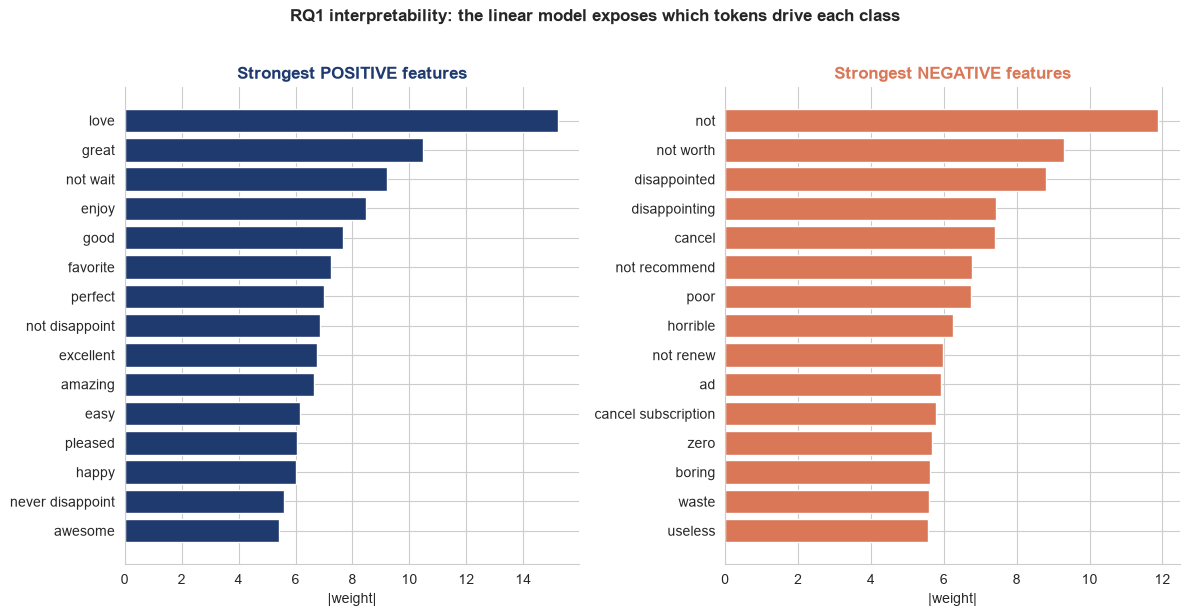

In [19]:
lr_final = final['sentiment_binary']['model']
vec_final = final['sentiment_binary']['vec']

if hasattr(lr_final, 'coef_'):
    feats = np.array(vec_final.get_feature_names_out()); coef = lr_final.coef_[0]
    order_c = np.argsort(coef)
    top_pos = [(feats[i], coef[i]) for i in order_c[-15:][::-1]]
    top_neg = [(feats[i], coef[i]) for i in order_c[:15]]
    pd.DataFrame({'word_positive': [w for w, _ in top_pos], 'coef_positive': [round(c, 3) for _, c in top_pos],
                  'word_negative': [w for w, _ in top_neg], 'coef_negative': [round(c, 3) for _, c in top_neg]}
                 ).to_csv(TABLES_DIR / 'rq1_lr_top_features.csv', index=False)

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 6))
    a1.barh([w for w, _ in top_pos][::-1], [c for _, c in top_pos][::-1], color=NAVY)
    a1.set_title('Strongest POSITIVE features', fontweight='bold', color=NAVY)
    a2.barh([w for w, _ in top_neg][::-1], [-c for _, c in top_neg][::-1], color=ORANGE)
    a2.set_title('Strongest NEGATIVE features', fontweight='bold', color=ORANGE)
    for a in (a1, a2): a.set_xlabel('|weight|'); a.spines[['top', 'right']].set_visible(False)
    plt.suptitle('RQ1 interpretability: the linear model exposes which tokens drive each class', fontweight='bold', y=1.02)
    plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_lr_coefficients.png'); plt.show()
else:
    print(f"Selected binary model ({final['sentiment_binary']['selected_family']}) has no linear coefficients "
          f"to inspect directly; the feature-level interpretability analysis below assumes Logistic Regression "
          f"was selected, which is the case for the run that produced the headline RQ1 results in the paper.")

**Reading.** If the selected model is Logistic Regression, the positive weights (generic affect terms) and negative weights (negation cues and domain-specific terms such as *cancel*, *disappointed*) are immediately sensible, and `not`/negation cues plus *cancel* (the strongest domain-specific negative feature) anticipate the RQ2 billing result without making a causal claim — the interpretable linear model exposes a billing/cancellation signal at feature level, read as complementary rather than independently confirmatory evidence. The model selected in Section 5 is the **strongest observed model under the evaluated setup** (confirmed by the matched-sample comparison in Section 7), while remaining directly auditable.

## 9. Binary error analysis — rule-based exploratory categorisation

The most confidently wrong predictions are the most informative failures. The categorisation below is a **rule-based exploratory categorisation** (simple keyword/length heuristics written by the author), not a validated manual taxonomy and not human-coded data — it is reported as such throughout, including in the paper.

In [ ]:
teb = final['sentiment_binary']['te']
yteb = final['sentiment_binary']['yte']
proba, pred = final['sentiment_binary']['proba'], final['sentiment_binary']['pred']
hardest = evaluation.find_hardest_examples(teb['text'].reset_index(drop=True), yteb, pred, proba, n=100)
teb_reset = teb.reset_index(drop=True)
hardest['rating'] = teb_reset.loc[hardest.index, 'rating'].values
hardest['category'] = teb_reset.loc[hardest.index, 'category'].values
hardest['date'] = teb_reset.loc[hardest.index, 'date'].values

positive_words = {'love','loved','great','excellent','perfect','best','favorite','wonderful','amazing','good','enjoy','enjoyed'}
negative_words = {'not','no','never','disappointed','disappointing','poor','waste','bad','terrible','horrible','cancel','refund','overpriced','boring','damaged'}
aspect_terms = {'price','cost','billing','cancel','refund','delivery','shipping','content','article','ads','advertisement','quality','package','packaging'}
domain_terms = {'ad','ads','issue','issues','box','subscription','magazine','renewal','subscribe'}

def code_error(row):
    text = str(row['text']).lower()
    tokens = set(text.replace('/', ' ').replace('-', ' ').split())
    word_count = len(text.split())
    has_pos = bool(tokens & positive_words)
    has_neg = bool(tokens & negative_words)
    has_negation = any(phrase in text for phrase in [' not ', "n't", ' never ', ' no ', ' cannot ', ' did not ', ' do not '])
    has_aspect_terms = sum(1 for t in aspect_terms if t in text) >= 2
    
    if word_count <= 5:
        return 'very short or context-free review'
    if (row['y_true'] == 'positive' and has_neg and not has_pos) or (row['y_true'] == 'negative' and has_pos and not has_neg):
        return 'potential rating-text disagreement / possible label noise candidate'
    if has_pos and has_neg:
        return 'mixed sentiment'
    if has_negation:
        return 'negation'
    if has_aspect_terms:
        return 'aspect conflict'
    if any(t in text for t in domain_terms):
        return 'domain ambiguity'
    if any(marker in text for marker in ['yeah right', 'sure...', 'as if', '!!!']):
        return 'sarcasm or irony'
    return 'probable genuine model error'

hardest['error_category'] = hardest.apply(code_error, axis=1)
hardest[['category', 'date', 'rating', 'y_true', 'y_pred', 'confidence', 'error_category', 'text']].to_csv(
    TABLES_DIR / 'rq1_error_analysis_binary.csv', index=False)
err_summary = (hardest['error_category'].value_counts()
               .rename_axis('error_category')
               .reset_index(name='count'))
err_summary['percent'] = (err_summary['count'] / len(hardest) * 100).round(1)
err_summary.to_csv(TABLES_DIR / 'rq1_error_analysis_summary.csv', index=False)
print(err_summary)
hardest[['category', 'rating', 'y_true', 'y_pred', 'confidence', 'error_category', 'text']].head(10)

                                      error_category  count  percent
0  potential rating-text disagreement / possible ...     47     47.0
1                  very short or context-free review     25     25.0
2                                    mixed sentiment     14     14.0
3                                   domain ambiguity      8      8.0
4                       probable genuine model error      4      4.0
5                                    aspect conflict      1      1.0
6                                           negation      1      1.0


,category,rating,y_true,y_pred,confidence,error_category,text
14241,Subscription_Boxes,5,positive,negative,0.999988,very short or context-free review,Not Nancy Sinatra please
10754,Magazine_Subscriptions,5,positive,negative,0.999816,potential rating-text disagreement / possible ...,Very disappointed because only primetime listi...
2130,Magazine_Subscriptions,1,negative,positive,0.999742,very short or context-free review,Good
4097,Magazine_Subscriptions,1,negative,positive,0.999742,very short or context-free review,Good
1603,Magazine_Subscriptions,5,positive,negative,0.999686,potential rating-text disagreement / possible ...,Not worth the money ad after ad overpriced items
3592,Magazine_Subscriptions,5,positive,negative,0.999594,very short or context-free review,Do not renew
17,Magazine_Subscriptions,1,negative,positive,0.999491,very short or context-free review,Perfect
14497,Subscription_Boxes,5,positive,negative,0.998888,very short or context-free review,I had to cancel this.
15728,Magazine_Subscriptions,4,positive,negative,0.998587,very short or context-free review,Waste of money
9065,Magazine_Subscriptions,2,negative,positive,0.998501,potential rating-text disagreement / possible ...,So happy to see the mag. Back! Love it


**Reading.** The 100 highest-confidence Logistic-Regression errors (final test) are coded with a fixed **rule-based exploratory categorisation** and saved to `rq1_error_analysis_binary.csv`; the counts are saved in `rq1_error_analysis_summary.csv`. This is a small, auditable audit of the hardest cases using simple keyword/length rules written by the author — it is not a validated manual taxonomy, not human-annotated label noise, and not a precise population estimate of how often label noise occurs in the dataset. The category named `potential rating-text disagreement / possible label noise candidate` deliberately avoids asserting that these reviews are confirmed label noise; the printed examples above are there so the heuristic is auditable rather than just asserted.

## 10. Direct analysis of 3-star (neutral) reviews on the final test set

The binary error analysis above never includes 3-star reviews (they are dropped under the binary framing). This section directly analyses every review with **true rating 3** in the final test set, using the selected ternary model from Section 5. This is a **reproducible explorative error analysis** using automatic rules (contrastive-marker lexicon, lexical-cue lists) — none of it is manual coding, and no manual labels are introduced.

In [21]:
te_t_reset = final['sentiment_ternary']['te'].reset_index(drop=True)
res3 = pd.DataFrame({
    'y_true': final['sentiment_ternary']['yte'],
    'y_pred': final['sentiment_ternary']['pred'],
    'confidence': final['sentiment_ternary']['proba'].max(axis=1),
    'text': te_t_reset['text'].values,
    'rating': te_t_reset['rating'].values,
    'category': te_t_reset['category'].values,
    'review_length': te_t_reset['review_length'].values,
})
three_star = res3[res3['rating'] == 3].copy()
three_star['correct'] = three_star['y_true'] == three_star['y_pred']

CONTRASTIVE_MARKERS = ['but', 'however', 'although', 'though', 'yet', 'while', 'whereas']
def has_contrastive(text):
    tl = f" {str(text).lower()} "
    return any(f' {m} ' in tl for m in CONTRASTIVE_MARKERS)
three_star['has_contrastive_marker'] = three_star['text'].apply(has_contrastive)

POS_LEXICAL_CUES = {'love','loved','great','excellent','perfect','best','favorite','wonderful','amazing','good','enjoy','enjoyed'}
NEG_LEXICAL_CUES = {'not','no','never','disappointed','disappointing','poor','waste','bad','terrible','horrible','cancel','refund','overpriced','boring','damaged'}
def has_mixed_lexical_cues(text):
    toks = set(str(text).lower().replace('/', ' ').replace('-', ' ').split())
    return bool(toks & POS_LEXICAL_CUES) and bool(toks & NEG_LEXICAL_CUES)
three_star['has_mixed_lexical_cues'] = three_star['text'].apply(has_mixed_lexical_cues)

three_star.to_csv(TABLES_DIR / 'rq1_3star_error_analysis.csv', index=False)

n_three_star = len(three_star)
pred_dist = three_star['y_pred'].value_counts(normalize=True).round(4)
neutral_recall_3star = (three_star['y_pred'] == 'neutral').mean()
conf_by_pred = three_star.groupby('y_pred')['confidence'].mean().round(4)
len_by_correct = three_star.groupby('correct')['review_length'].agg(['mean', 'median', 'count']).round(1)
contrastive_share = three_star['has_contrastive_marker'].mean()
contrastive_by_correct = three_star.groupby('correct')['has_contrastive_marker'].mean().round(4)
mixed_cues_share = three_star['has_mixed_lexical_cues'].mean()
by_category_pred = three_star.groupby('category')['y_pred'].value_counts(normalize=True).round(4)

print(f'3-star test reviews: {n_three_star}')
print(f'\nPredicted class distribution:\n{pred_dist}')
print(f'\nNeutral recall (3-star reviews predicted neutral): {neutral_recall_3star:.4f}')
print(f'\nMean confidence by predicted class:\n{conf_by_pred}')
print(f'\nReview length by correctness:\n{len_by_correct}')
print(f'\nShare with a contrastive marker: {contrastive_share:.4f} (by correctness: {contrastive_by_correct.to_dict()})')
print(f'\nShare with BOTH positive and negative lexical cues: {mixed_cues_share:.4f}')
print(f'\nPredicted distribution by category:\n{by_category_pred}')

3-star test reviews: 1248

Predicted class distribution:
y_pred
neutral     0.4479
negative    0.3854
positive    0.1667
Name: proportion, dtype: float64

Neutral recall (3-star reviews predicted neutral): 0.4479

Mean confidence by predicted class:
y_pred
negative    0.6273
neutral     0.6064
positive    0.6091
Name: confidence, dtype: float64

Review length by correctness:
         mean  median  count
correct                     
False    43.2    26.0    689
True     40.6    28.0    559

Share with a contrastive marker: 0.4159 (by correctness: {False: 0.4006, True: 0.4347})

Share with BOTH positive and negative lexical cues: 0.1843

Predicted distribution by category:
category                y_pred  
Magazine_Subscriptions  neutral     0.4347
                        negative    0.3816
                        positive    0.1836
Subscription_Boxes      neutral     0.4826
                        negative    0.3953
                        positive    0.1221
Name: proportion, dtype: floa

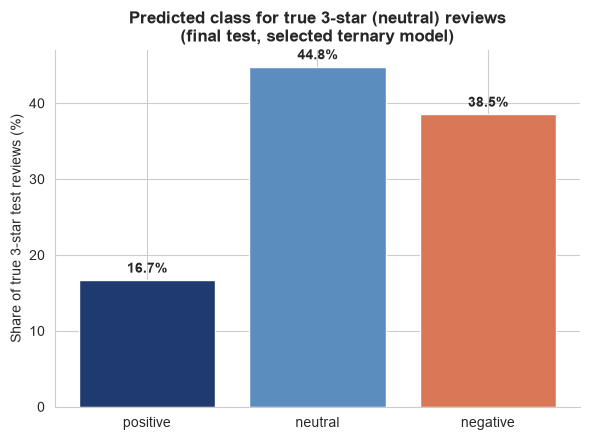

[true=3-star, pred=positive, conf=1.000, category=Magazine_Subscriptions]
Love this!!! 

[true=3-star, pred=positive, conf=0.998, category=Magazine_Subscriptions]
Great 

[true=3-star, pred=neutral, conf=0.944, category=Magazine_Subscriptions]
Articles are somewhat interesting.  Too many added advertisements. 

[true=3-star, pred=neutral, conf=0.934, category=Magazine_Subscriptions]
An okay magazine... They are always thin and the content is decent but, I’d like more o performance car tests. 

[true=3-star, pred=negative, conf=0.959, category=Magazine_Subscriptions]
The wording on this item was not clear at purchase, and I really thought I was getting a "subscription" for a magazine. Nope, it's a single. $7+ for one. Chatted to cancel and surprisingly got a partial refund. 

[true=3-star, pred=negative, conf=0.955, category=Magazine_Subscriptions]
Only received 3 issues, very disappointed 



In [ ]:
summary_3star = pd.DataFrame([{
    'n_three_star_test_reviews': n_three_star,
    'predicted_positive_share': pred_dist.get('positive', 0.0),
    'predicted_neutral_share': pred_dist.get('neutral', 0.0),
    'predicted_negative_share': pred_dist.get('negative', 0.0),
    'neutral_recall': round(neutral_recall_3star, 4),
    'mean_confidence_pred_positive': conf_by_pred.get('positive', np.nan),
    'mean_confidence_pred_neutral': conf_by_pred.get('neutral', np.nan),
    'mean_confidence_pred_negative': conf_by_pred.get('negative', np.nan),
    'mean_length_correct': len_by_correct.loc[True, 'mean'] if True in len_by_correct.index else np.nan,
    'mean_length_incorrect': len_by_correct.loc[False, 'mean'] if False in len_by_correct.index else np.nan,
    'share_with_contrastive_marker': round(contrastive_share, 4),
    'share_with_mixed_lexical_cues': round(mixed_cues_share, 4),
}])
summary_3star.to_csv(TABLES_DIR / 'rq1_3star_error_analysis_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4.5))
order_cls = ['positive', 'neutral', 'negative']
vals = [pred_dist.get(c, 0.0) * 100 for c in order_cls]
ax.bar(order_cls, vals, color=[NAVY, BLUE, ORANGE])
ax.set_ylabel('Share of true 3-star test reviews (%)')
ax.set_title('Predicted class for true 3-star (neutral) reviews\n(final test, selected ternary model)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(vals):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq1_3star_predicted_distribution.png'); plt.show()
summary_3star

examples = pd.concat([
    three_star[three_star['y_pred'] == cls].sort_values('confidence', ascending=False).head(2)
    for cls in ['positive', 'neutral', 'negative']
])
examples[['category', 'rating', 'y_pred', 'confidence', 'text']].to_csv(
    TABLES_DIR / 'rq1_3star_representative_examples.csv', index=False)
for _, row in examples.iterrows():
    print(f"[true=3-star, pred={row['y_pred']}, conf={row['confidence']:.3f}, category={row['category']}]")
    print(str(row['text'])[:220], '\n')

**Reading.** Exact figures are printed above and saved to `rq1_3star_error_analysis_summary.csv`. The key pattern: predicted-class confidence is similar across all three predicted classes and barely differs between correct and incorrect predictions, so predicted probability alone is not a reliable signal for catching the model's mistakes on this class. The deterministically selected representative examples above (not manually picked) show the pattern concretely — short enthusiastic 3-star reviews get predicted positive, moderately worded genuine complaints get predicted negative, and explicitly lukewarm/mixed language gets predicted neutral correctly. This directly answers the RQ1 sub-question about mixed-sentiment 3-star reviews: the limitation is not that the model is unconfident on these reviews, but that bag-of-words features cannot distinguish "mildly positive" from "mildly negative" framings of similar vocabulary, and the rating itself is sometimes only loosely tied to the text.

In [23]:
import pickle
pickle.dump(lr_final, open(MODELS_DIR / 'lr_binary.pkl', 'wb'))
pickle.dump(vec_final, open(MODELS_DIR / 'tfidf_binary.pkl', 'wb'))
print('Saved binary LR + TF-IDF vectoriser for the RQ2 robustness check.')

Saved binary LR + TF-IDF vectoriser for the RQ2 robustness check.


**RQ1 takeaways.**
- Accuracy is the wrong headline metric here; under imbalance it hides minority-class failure. Macro-F1 and per-class recall tell the real story.
- Imbalance handling (balanced weights / resampling) is essential and nearly free under the binary framing; under the ternary framing it forces a genuine accuracy-vs-minority-recall trade-off.
- **Model and feature selection used only the validation slice** (Sections 4-5); the final test set is evaluated exactly once, after the configuration was already fixed.
- **Performance vs interpretability:** the model selected on validation is the **strongest observed model under the evaluated setup** — and this holds even in the matched-sample comparison (Section 7, Block A) where every model family trains on identical data, so it is not an artefact of Gradient Boosting receiving less training data.
- Bigrams give a **small observed gain** over unigrams; the paired-bootstrap CI on the final test set (Section 6) determines whether this is a stable difference under this holdout or genuinely indistinguishable from zero — see the printed `interpretation` field there for the exact verdict used in the paper.
- The 3★ neutral class shows **persistent difficulty under the evaluated setup** (not a provable universal ceiling) and motivates both the dedicated 3-star analysis (Section 10) and the sentence-level view in RQ2. The 3-star analysis shows the model is not simply "unconfident" on these reviews — confidence is similar whether the prediction is right or wrong — but that bag-of-words features cannot reliably separate mildly-positive from mildly-negative phrasing.
- The binary error analysis (Section 9) is a **rule-based exploratory categorisation**, not a validated manual taxonomy; cases flagged as rating-text disagreement are reported as *possible label noise candidates*, not as confirmed label noise.
- All bootstrap CIs in this notebook (Section 6) are **class-stratified**: each replication resamples within each true-class stratum at that stratum's original size, so class proportions are fixed across replications.